# Week 4 Assignment - CIFAR-10 Image Classification (ANN vs CNN)

**Name:** Parth Moholkar
**Track:** Data Science Internship, Celebal Technologies

## Objective
Build an image classifier for CIFAR-10 using an Artificial Neural Network and a Convolutional Neural Network, then compare how much different training strategies (regularization, callbacks, augmentation, transfer learning) move the needle on test accuracy.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.20.0
GPU available: True


## 2. Loading the CIFAR-10 Dataset
CIFAR-10 has 60,000 32x32 RGB images spread across 10 classes: 50,000 for training and 10,000 for testing. It is fetched from the Hugging Face Hub mirror (`uoft-cs/cifar10`), served off Hugging Face's own CDN, with the original Keras loader kept as a fallback in case the Hub is unreachable in a given environment.

In [2]:
!pip install -q -U datasets pyarrow

**Restart the runtime now** (`Runtime -> Restart runtime`), then continue with `Runtime -> Run all`.

Colab preloads its own copy of `pyarrow` at startup; installing a newer one above does not replace that copy mid-session, which is what causes a binary-incompatibility error if the next cell is run immediately. Restarting clears that stale copy so the freshly installed version loads cleanly. This only needs to be done once per session — after the restart, the notebook runs top to bottom without interruption.

In [3]:
try:
    from datasets import load_dataset
    hf_ds = load_dataset("uoft-cs/cifar10")

    def _to_numpy(split):
        images = np.stack([np.array(img) for img in split["img"]])
        labels = np.array(split["label"])
        return images, labels

    train_images, train_labels = _to_numpy(hf_ds["train"])
    test_images, test_labels = _to_numpy(hf_ds["test"])
except Exception as e:
    print("Hugging Face mirror unavailable, falling back to the Keras loader:", e)
    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training set:", train_images.shape, train_labels.shape)
print("Test set:", test_images.shape, test_labels.shape)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training set: (50000, 32, 32, 3) (50000,)
Test set: (10000, 32, 32, 3) (10000,)


## 3. Exploring the Data

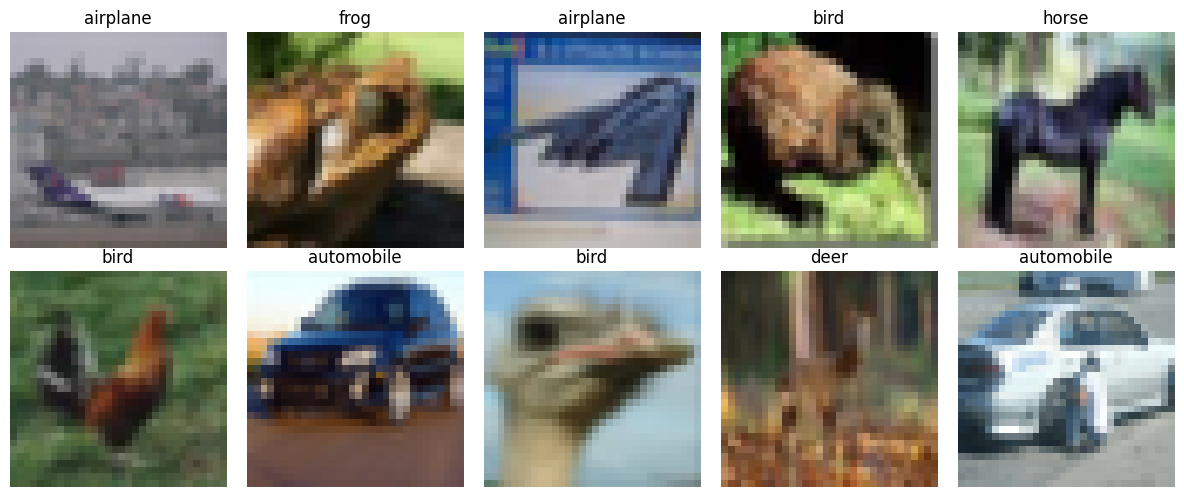

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(train_images[idx])
    ax.set_title(class_names[train_labels[idx]])
    ax.axis('off')
plt.tight_layout()
plt.show()

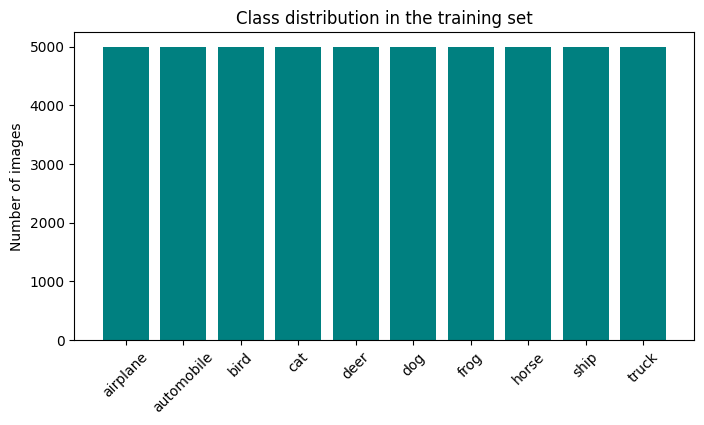

In [5]:
unique, counts = np.unique(train_labels, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in unique], counts, color='teal')
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Class distribution in the training set")
plt.show()

## 4. Preprocessing
Pixel values are rescaled from 0-255 to 0-1. A validation split is carved out once from the training set so every model below is validated on the exact same images, which keeps the comparison fair.

In [6]:
train_images_scaled = train_images.astype("float32") / 255.0
test_images_scaled = test_images.astype("float32") / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    train_images_scaled, train_labels,
    test_size=0.1, random_state=42, stratify=train_labels
)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = test_images_scaled.reshape(test_images_scaled.shape[0], -1)

print("Flattened ANN input size:", X_train_flat.shape[1])

Flattened ANN input size: 3072


## 5. Shared Training Callbacks
The same two callbacks are reused for every model: early stopping on validation accuracy so training stops once the model stops improving, and a learning-rate cut once validation loss plateaus. A fresh instance is created per model so their internal state never carries over between runs.

In [7]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=4, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2
        )
    ]

## 6. Model A - Artificial Neural Network (ANN)
An ANN treats the image as one long flat vector of pixel values, so it has no built-in notion that two pixels are neighbours - that spatial relationship is thrown away before the first layer even runs. Batch normalization after each dense layer stabilizes the forward pass, and dropout limits overfitting on the very high-dimensional flattened input. Labels stay as plain integers, so `sparse_categorical_crossentropy` is used instead of one-hot encoding them first.

In [8]:
def build_ann():
    model = models.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

ann_model = build_ann()
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,744,650 (14.28 MB)

 Trainable params: 3,741,578 (14.27 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [9]:
ann_history = ann_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=25,
    batch_size=128,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.3340 - loss: 1.9061 - val_accuracy: 0.3220 - val_loss: 1.9339 - learning_rate: 0.0010
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3964 - loss: 1.6846 - val_accuracy: 0.3446 - val_loss: 1.8015 - learning_rate: 0.0010
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4252 - loss: 1.6094 - val_accuracy: 0.3906 - val_loss: 1.7057 - learning_rate: 0.0010
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4361 - loss: 1.5713 - val_accuracy: 0.3976 - val_loss: 1.6879 - learning_rate: 0.0010
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4421 - loss: 1.5558 - val_accuracy: 0.4192 - val_loss: 1.6188 - learning_rate: 0.0010
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4514 - loss: 1.5348 - val_accuracy: 0.4542 - val_loss: 1.5367 - learning_rate: 0.0010
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4520 - loss: 1.5241 

In [10]:
ann_test_loss, ann_test_acc = ann_model.evaluate(X_test_flat, test_labels, verbose=0)
print(f"ANN test accuracy: {ann_test_acc:.4f}")
print(f"ANN test loss: {ann_test_loss:.4f}")

ANN test accuracy: 0.5385
ANN test loss: 1.3044


## 7. Model B - Convolutional Neural Network (CNN)
A convolution filter slides across small local patches, so every output value depends on a neighbourhood of pixels instead of the whole image at once - this is what an ANN cannot do. `padding='same'` keeps the spatial size unchanged after each convolution so the network can go deeper before anything shrinks, and each `MaxPooling2D` layer applies a stride of 2, halving the resolution while keeping the strongest activations. `GlobalAveragePooling2D` replaces the usual flatten-into-dense step, which cuts the parameter count sharply and helps generalization.

In [11]:
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,122 (617.66 KB)

 Trainable params: 157,674 (615.91 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=128,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4943 - loss: 1.3875 - val_accuracy: 0.2302 - val_loss: 2.9398 - learning_rate: 0.0010
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6523 - loss: 0.9848 - val_accuracy: 0.4622 - val_loss: 1.5699 - learning_rate: 0.0010
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7184 - loss: 0.8126 - val_accuracy: 0.5964 - val_loss: 1.1348 - learning_rate: 0.0010
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7611 - loss: 0.6939 - val_accuracy: 0.6588 - val_loss: 0.9828 - learning_rate: 0.0010
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7934 - loss: 0.6030 - val_accuracy: 0.6796 - val_loss: 0.9332 - learning_rate: 0.0010
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8198 - loss: 0.5307 - val_accuracy: 0.6526 - val_loss: 1.0572 - learning_rate: 0.0010
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8413 - loss: 0

In [13]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_images_scaled, test_labels, verbose=0)
print(f"CNN test accuracy: {cnn_test_acc:.4f}")
print(f"CNN test loss: {cnn_test_loss:.4f}")

CNN test accuracy: 0.8139
CNN test loss: 0.7761


## 8. ANN vs CNN - Learning Curves

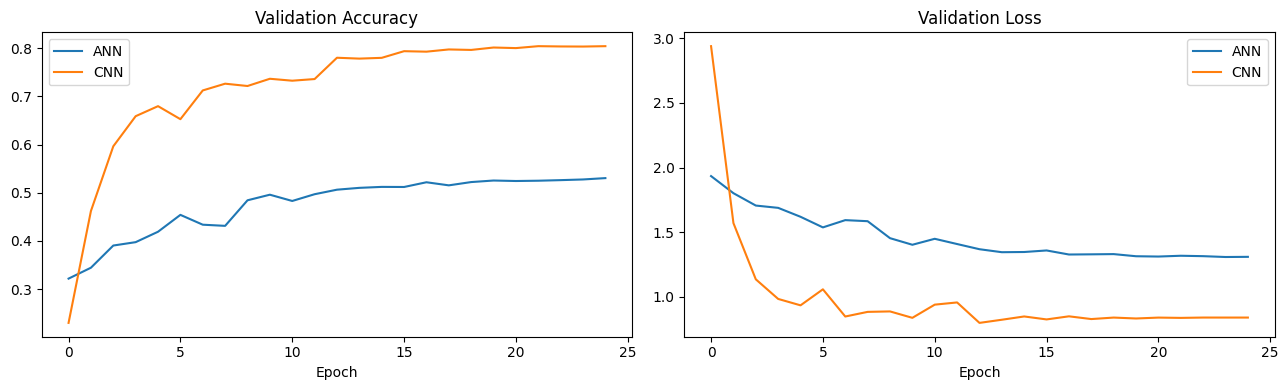

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ann_history.history['val_accuracy'], label='ANN')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN')
axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(ann_history.history['val_loss'], label='ANN')
axes[1].plot(cnn_history.history['val_loss'], label='CNN')
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Training Strategy - Data Augmentation
Random flips, rotations, small translations and zooms are applied on the fly during training only, so the network rarely sees the exact same image twice across epochs. This acts as a regularizer and usually narrows the gap between training and validation accuracy without collecting a single new image.

In [15]:
augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1)
])

def build_augmented_cnn():
    inputs = layers.Input(shape=(32, 32, 3))
    x = augmenter(inputs)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

aug_cnn_model = build_augmented_cnn()
aug_history = aug_cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=128,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.3533 - loss: 1.7265 - val_accuracy: 0.2884 - val_loss: 2.0303 - learning_rate: 0.0010
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4929 - loss: 1.4026 - val_accuracy: 0.5256 - val_loss: 1.3225 - learning_rate: 0.0010
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5471 - loss: 1.2574 - val_accuracy: 0.5356 - val_loss: 1.3593 - learning_rate: 0.0010
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5856 - loss: 1.1646 - val_accuracy: 0.5600 - val_loss: 1.2583 - learning_rate: 0.0010
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6132 - loss: 1.0944 - val_accuracy: 0.6144 - val_loss: 1.0872 - learning_rate: 0.0010
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6366 - loss: 1.0316 - val_accuracy: 0.6028 - val_loss: 1.1572 - learning_rate: 0.0010
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6544 - loss: 0

In [16]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(test_images_scaled, test_labels, verbose=0)
print(f"Augmented CNN test accuracy: {aug_test_acc:.4f}")
print(f"Augmented CNN test loss: {aug_test_loss:.4f}")

Augmented CNN test accuracy: 0.7623
Augmented CNN test loss: 0.6997


## 10. Training Strategy - Transfer Learning (Bonus)
Transfer learning reuses convolutional filters that were already learned on millions of ImageNet images instead of learning everything from scratch on CIFAR-10's 50,000. Images are resized to 96x96 to satisfy MobileNetV2's minimum input size. Training happens in two phases: first the backbone stays fully frozen while only the new classification head learns (feature extraction), then the top of the backbone is unfrozen and trained at a much lower learning rate so its filters adapt slightly to CIFAR-10 (fine-tuning). This section is heavier on compute than the two models above, so it can be skipped if runtime is limited.

In [17]:
resize_layer = layers.Resizing(96, 96)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(32, 32, 3))
x = resize_layer(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)  # undo the earlier 0-1 scaling for this backbone
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

tl_model = models.Model(inputs, outputs)
tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 10a. Phase 1 - Feature Extraction (backbone frozen)

In [18]:
tl_history = tl_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=128,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 101ms/step - accuracy: 0.7890 - loss: 0.6281 - val_accuracy: 0.8382 - val_loss: 0.4778 - learning_rate: 0.0010
Epoch 2/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8524 - loss: 0.4303 - val_accuracy: 0.8514 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 3/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8712 - loss: 0.3768 - val_accuracy: 0.8556 - val_loss: 0.4251 - learning_rate: 0.0010
Epoch 4/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8810 - loss: 0.3424 - val_accuracy: 0.8598 - val_loss: 0.4072 - learning_rate: 0.0010
Epoch 5/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8913 - loss: 0.3085 - val_accuracy: 0.8580 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 6/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8996 - loss: 0.2881 - val_accuracy: 0.8600 - val_loss: 0.4265 - learning_rate: 0.0010
Epoch 7/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9140 - loss: 0.2445 

In [19]:
fe_test_loss, fe_test_acc = tl_model.evaluate(test_images_scaled, test_labels, verbose=0)
print(f"Feature extraction test accuracy: {fe_test_acc:.4f}")
print(f"Feature extraction test loss: {fe_test_loss:.4f}")

Feature extraction test accuracy: 0.8692
Feature extraction test loss: 0.3968


### 10b. Phase 2 - Fine-Tuning (top of the backbone unfrozen)
Only the last 30 layers of MobileNetV2 are unfrozen, and its `BatchNormalization` layers are kept frozen even within that block - unfreezing batch norm on a small, non-ImageNet-scale batch tends to destabilize training. The learning rate is dropped to 1e-5 so the pretrained weights shift gently instead of being overwritten.

In [20]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

fine_tune_history = tl_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=128,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - accuracy: 0.9225 - loss: 0.2204 - val_accuracy: 0.8732 - val_loss: 0.3959 - learning_rate: 1.0000e-05
Epoch 2/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9343 - loss: 0.1914 - val_accuracy: 0.8754 - val_loss: 0.3921 - learning_rate: 1.0000e-05
Epoch 3/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9432 - loss: 0.1670 - val_accuracy: 0.8778 - val_loss: 0.3891 - learning_rate: 1.0000e-05
Epoch 4/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9475 - loss: 0.1517 - val_accuracy: 0.8798 - val_loss: 0.3899 - learning_rate: 1.0000e-05
Epoch 5/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9523 - loss: 0.1364 - val_accuracy: 0.8818 - val_loss: 0.3917 - learning_rate: 1.0000e-05
Epoch 6/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9586 - loss: 0.1224 - val_accuracy: 0.8832 - val_loss: 0.3964 - learning_rate: 5.0000e-06


In [21]:
tl_test_loss, tl_test_acc = tl_model.evaluate(test_images_scaled, test_labels, verbose=0)
print(f"Fine-tuned test accuracy: {tl_test_acc:.4f}")
print(f"Fine-tuned test loss: {tl_test_loss:.4f}")
print(f"Improvement over feature extraction alone: {tl_test_acc - fe_test_acc:+.4f}")

Fine-tuned test accuracy: 0.8845
Fine-tuned test loss: 0.3775
Improvement over feature extraction alone: +0.0153


## 11. Final Comparison

In [22]:
results = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation", "Transfer Learning (MobileNetV2)"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc, tl_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss, tl_test_loss]
})
results

,Model,Test Accuracy,Test Loss
0,ANN,0.5385,1.304351
1,CNN,0.8139,0.776054
2,CNN + Augmentation,0.7623,0.699720
3,Transfer Learning (MobileNetV2),0.8845,0.377547


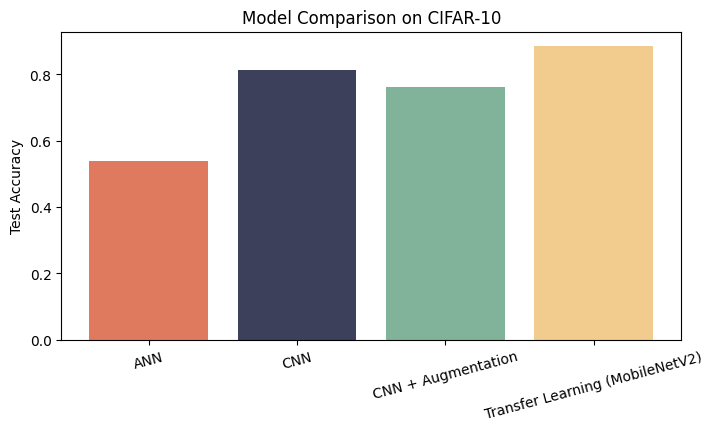

In [23]:
plt.figure(figsize=(8, 4))
plt.bar(results["Model"], results["Test Accuracy"],
        color=['#e07a5f', '#3d405b', '#81b29a', '#f2cc8f'])
plt.ylabel("Test Accuracy")
plt.title("Model Comparison on CIFAR-10")
plt.xticks(rotation=15)
plt.show()

## 12. Closer Look - Confusion Matrix
The best model from the table above is inspected class by class to see which categories it confuses most - usually visually similar pairs like cat/dog or automobile/truck.

Best performing model: Transfer Learning (MobileNetV2)


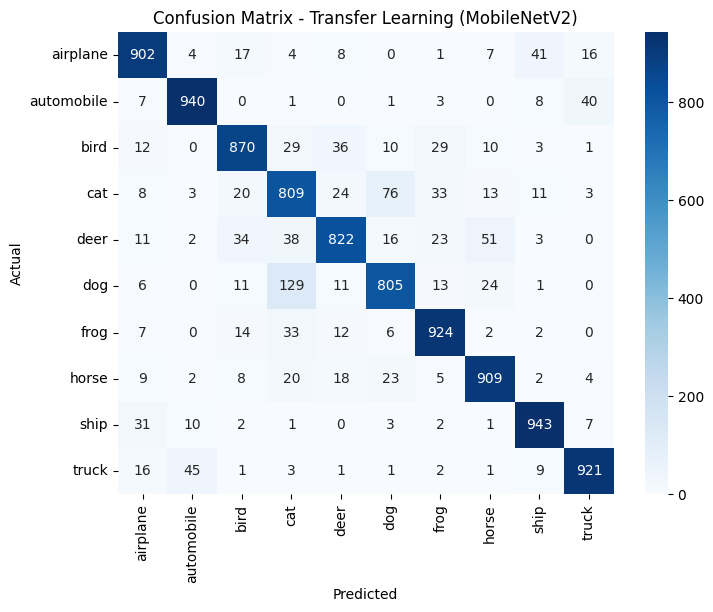

              precision    recall  f1-score   support

    airplane       0.89      0.90      0.90      1000
  automobile       0.93      0.94      0.94      1000
        bird       0.89      0.87      0.88      1000
         cat       0.76      0.81      0.78      1000
        deer       0.88      0.82      0.85      1000
         dog       0.86      0.81      0.83      1000
        frog       0.89      0.92      0.91      1000
       horse       0.89      0.91      0.90      1000
        ship       0.92      0.94      0.93      1000
       truck       0.93      0.92      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [24]:
best_idx = results["Test Accuracy"].idxmax()
best_name = results.loc[best_idx, "Model"]
print("Best performing model:", best_name)

model_lookup = {
    "ANN": (ann_model, X_test_flat),
    "CNN": (cnn_model, test_images_scaled),
    "CNN + Augmentation": (aug_cnn_model, test_images_scaled),
    "Transfer Learning (MobileNetV2)": (tl_model, test_images_scaled)
}

best_model, best_input = model_lookup[best_name]
predictions = np.argmax(best_model.predict(best_input, verbose=0), axis=1)

cm = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

print(classification_report(test_labels, predictions, target_names=class_names))

## 13. Conclusion
- A flat ANN loses spatial structure before the first layer even runs, so it can still learn from CIFAR-10 but plateaus well below the CNN.
- Convolution, padding and strided pooling let the CNN build features hierarchically - edges and colours early on, shapes and object parts deeper in - which is why it beats the ANN by a clear margin.
- ReLU is used through both networks instead of sigmoid or tanh because it does not saturate for positive inputs, which keeps gradients from vanishing during backpropagation across several stacked layers.
- Batch normalization and dropout are two different regularizers working together - one rescales activations between layers, the other randomly drops neurons - and both narrow the train/validation accuracy gap.
- Data augmentation effectively grows the training set for free, which further reduces overfitting on the CNN.
- Transfer learning gets an extra boost because MobileNetV2's filters were already trained on millions of ImageNet images, so the network only needs to learn how to recombine existing features for CIFAR-10's 10 classes rather than learning filters from zero.
- Fine-tuning the top of that backbone afterward, at a much lower learning rate, lets those filters adapt slightly to CIFAR-10's specific classes on top of the ImageNet features they already have, which pushes accuracy higher than feature extraction alone.

## Notes for Reviewer
- A GPU runtime (Colab: Runtime > Change runtime type > GPU) is recommended; the transfer learning section in particular is slow on CPU.
- Section 10 (Transfer Learning) is marked as a bonus strategy since it was not asked for explicitly, and can be skipped if the runtime is time-constrained - the rest of the notebook runs independently of it.
- Every `fit()` call uses `restore_best_weights=True`, so evaluation is always on the best validation checkpoint, not the last epoch.